# &nbsp;&nbsp;&nbsp;&nbsp;<span style="color: #1387abff;">Chapter 2: </span>模型学习中的技巧

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;由于模型的学习技巧是是非常值得研究的内容，所以第二章并不那么简短。上一小节中，我们通过使用更先进的优化器一定程度提升了模型表现。这一小节将为你介绍初始化的技巧。

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color: #dab70aff;">2.2 初始化的技巧</span>

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;在我们在的前两章中，参数矩阵的初始化方式一直是使用numpy库的随机初始化。事实上，numpy的随机是使用高斯分布的随机( 或正态分布 )，生成均值为0而标准差为1的数据。你可能已经发现所有参数矩阵都使用同一种随机方式未免有些鲁莽，研究者们也注意到了这一点。下面让我们看看这样做的坏处。

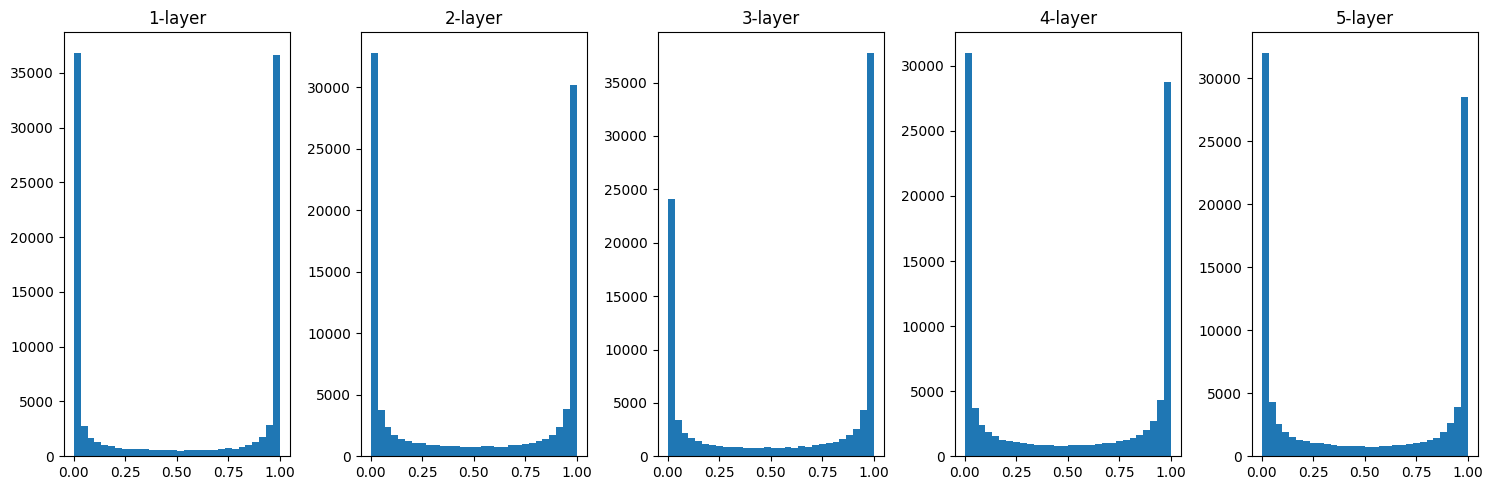

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_n(x):
    return 1/(1 + np.exp(-x))
def activation_experiment_sigmoid(std):
    x = np.random.randn(1000,100)
    node_num = 100
    hidden_layer_size = 5
    activations = {}

    for i in range(hidden_layer_size):
        if i != 0:
            x = activations[i-1]

        w = np.random.randn(node_num, node_num) * std

        z = np.dot(x,w)
        a = sigmoid_n(z)
        activations[i] = a

    plt.figure(figsize=(15, 5))

    for i,a in activations.items():
        plt.subplot(1,len(activations),i+1)
        plt.title(str(i+1) + '-layer')
        plt.hist(a.flatten(),30, range=(0,1))

    plt.tight_layout()
    plt.show()
if __name__ == '__main__':
    activation_experiment_sigmoid(1)

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;这是在干什么？我们做了一个极简的五层全连接神经网络，没有反向传播内容，每一层参数矩阵都是100 × 100的高斯分布随机矩阵。我们观察每一层经过sigmoid函数处理后的激活值分布( 展平所有数据)，发现激活值在0与1附近尤为集中，中间则平坦稀疏。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;这是好事吗？这意味着什么？实际上，这种两极分化的情况被称为‘梯度饱和’，非常值得警惕。Sigmoid函数在输入值的绝对值较大时（对应激活值接近0或1），其导数（梯度）会变得非常小，接近于0。这些微小的梯度在反向传播中由链式法则作用到网络更前方的梯度，导致网络更新过程异常缓慢。同时，大量的0与1严重削弱了网络的非线性表达能力，这使得网络更像一个简单的线性判断模型。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;问题在哪里？我们选择了标准差为1的高斯分布，那么其他标准差会使这个网络不一样吗？我们看看std = 0.01的情况。

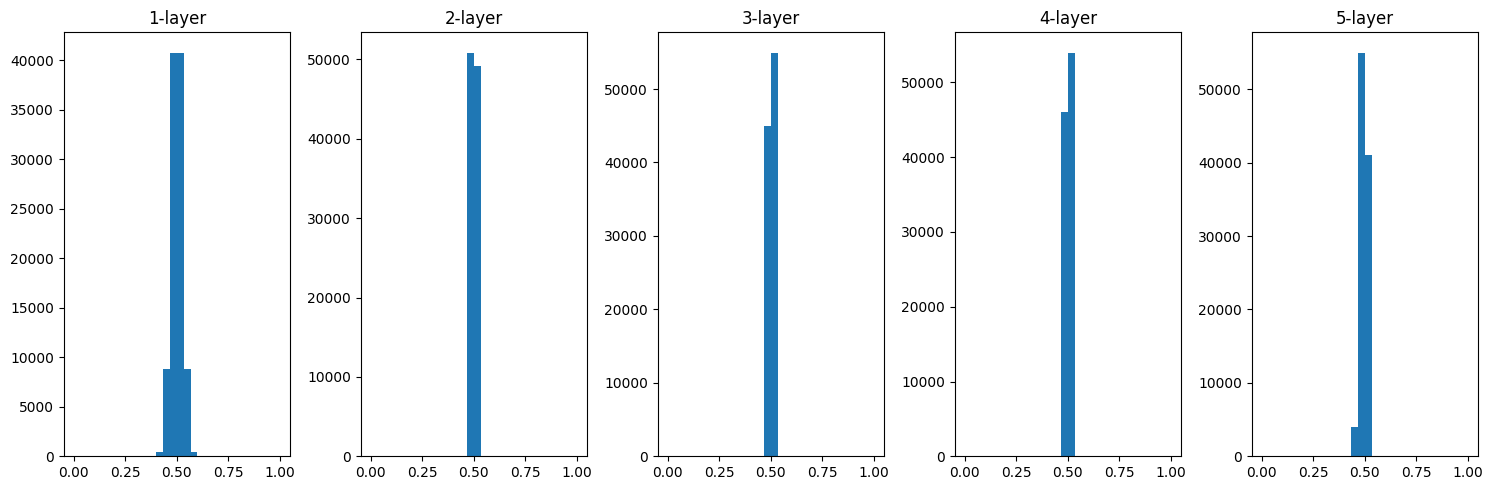

In [3]:
if __name__ == '__main__':
    activation_experiment_sigmoid(0.01)

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;截然不同。所有激活值集中在0.5左右，确实缓解了梯度消失问题。然而，我们的模型表达能力依旧被削弱了，这种激活值集中被称为"​表征坍缩​"。如果所有层都输出差不多的结果，还要那么多层做什么呢？网络的诸多神经元实际上退化了。所以这样并不健康。

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;我们想要什么样的激活值分布？宽度广，高度均匀，这样既能避免梯度消失与爆炸，又有很强的表达能力。用更严谨的语言说，为了保持网络中信号的良好流动，每一层输出的方差应该尽量等于其输入的方差。Xavier初始化几乎可以做到这一点，让我们看看。

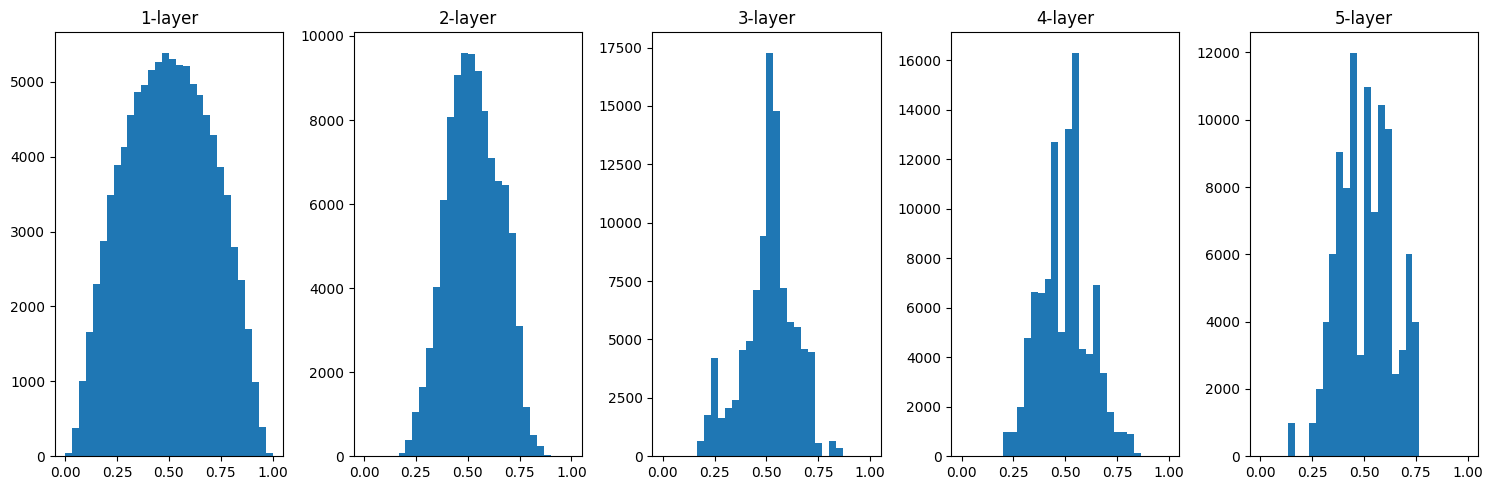

In [4]:
import math
if __name__ == '__main__':
    activation_experiment_sigmoid(1/math.sqrt(100))

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;这些图片看起来很健康。Xavier初始化做的事就是设定每一层的高斯分布标准差为1/math.sqrt(n)，其中n是前一隐藏层的节点数( 前一层参数矩阵列数 )。Xavier背后的原理可以参考原论文。下面我们看看将sigmoid函数换为ReLU函数会发生什么。

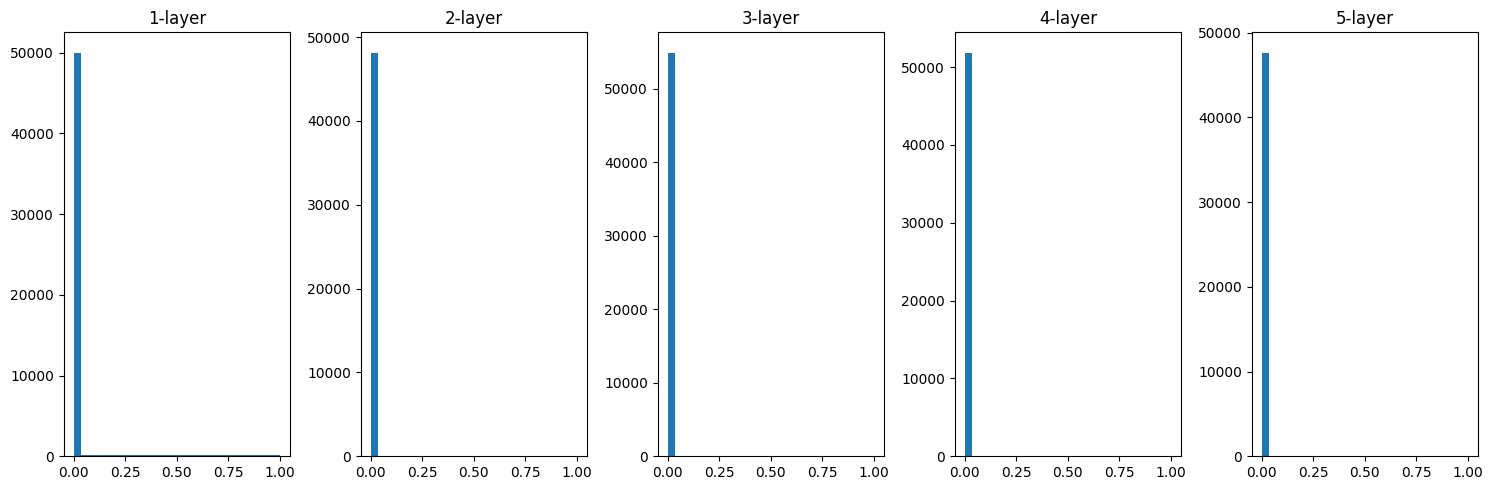

In [5]:
def ReLU_n(x):
    mask = (x<=0) 
    out = x.copy()
    out[mask] = 0
    return out

def activation_experiment_ReLU(std):
    x = np.random.randn(1000,100)
    node_num = 100
    hidden_layer_size = 5
    activations = {}

    for i in range(hidden_layer_size):
        if i != 0:
            x = activations[i-1]

        w = np.random.randn(node_num, node_num) * std

        z = np.dot(x,w)
        a = ReLU_n(z)
        activations[i] = a

    plt.figure(figsize=(15, 5))

    for i,a in activations.items():
        plt.subplot(1,len(activations),i+1)
        plt.title(str(i+1) + '-layer')
        plt.hist(a.flatten(),30, range=(0,1))

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    activation_experiment_ReLU(1)

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;非常恶劣的健康状况，让我们请出He( Kaiming )初始化。

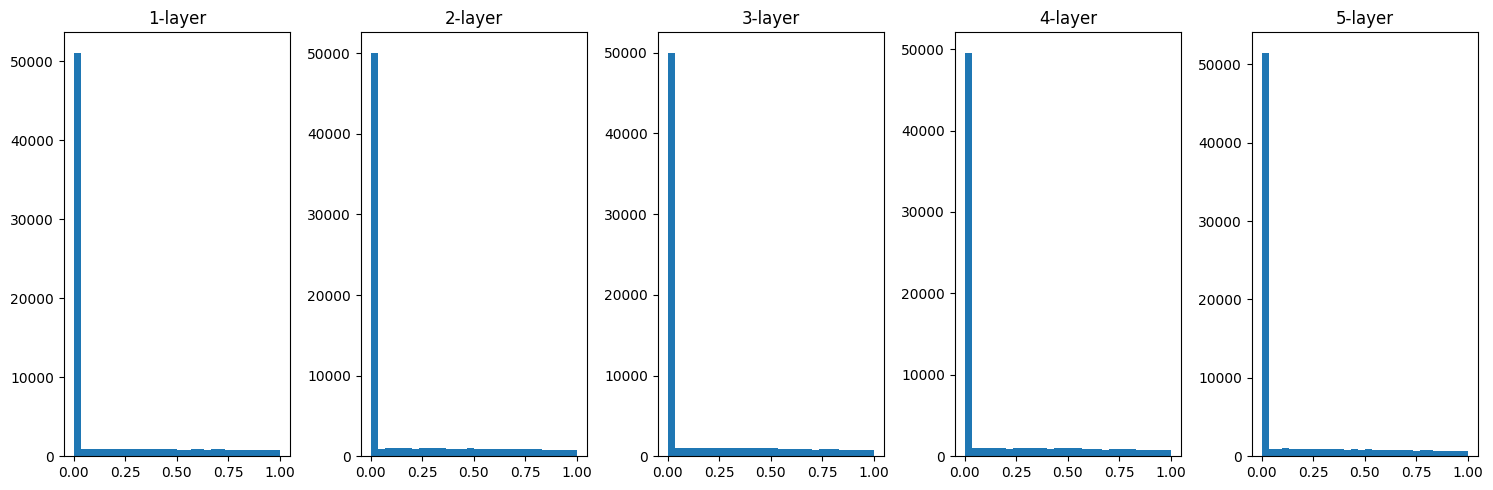

In [6]:
if __name__ == '__main__':
    activation_experiment_ReLU(math.sqrt(2/100))

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;由于ReLU函数的特性，大量值集中于0，而大于0的部分呈现出长方形，因此我们可以认为是健康的。He初始化选取math.sqrt(2/n)作为标准差，可以浅显理解为ReLU的结果去掉了半个实数轴，因此需要两倍宽度。关于He初始化的原理，可以参考何恺明老师的文章。接下来，我们在之前的神经网络中试一试先进的初始化方法的威力。

In [7]:
import Chapter_the_first_FCNN as FCNN
class Twolayersnet_n:
    def __init__(self,input_size,hidden_size,output_size):
        self.params = {}#下面使用He初始化
        self.params['W1'] = np.random.randn(input_size,hidden_size)*math.sqrt(2/input_size)
        self.params['W2'] = np.random.randn(hidden_size,output_size)*math.sqrt(2/hidden_size)
        self.params['B1'] = np.zeros((1,hidden_size))
        self.params['B2'] = np.zeros((1,output_size))

        self.layers = FCNN.OrderedDict()
        self.layers['Affine1'] = FCNN.Affine(self.params['W1'],self.params['B1'])
        self.layers['ReLU'] = FCNN.ReLU()
        self.layers['Affine2'] = FCNN.Affine(self.params['W2'],self.params['B2'])

        self.lastlayer = FCNN.SoftmaxWithLoss()
        
    def predict(self,x):
        for layer in self.layers.values():
            x= layer.forward(x)
        return x
        
    def loss(self,x,t):
        y = self.predict(x)
        return self.lastlayer.forward(y,t)

    def accuracy(self,x,t):
        y = self.predict(x)
        y = np.argmax(y,axis=1)
        if t.ndim !=1: t = np.argmax(t,axis=1)
        return np.sum(y==t)/float(x.shape[0])
        
    def gradient(self, x, t):
        self.loss(x, t)
        dout = 1
        dout = self.lastlayer.backward(dout)
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        grads = {}
        grads['W1'] = self.layers['Affine1'].dW
        grads['W2'] = self.layers['Affine2'].dW
        grads['B1'] = self.layers['Affine1'].db
        grads['B2'] = self.layers['Affine2'].db

        return grads

In [8]:
if __name__ == '__main__':
    (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = FCNN.mnist.load_data()
    x_train = x_train_raw.reshape(x_train_raw.shape[0], -1)/255.0
    x_test = x_test_raw.reshape(x_test_raw.shape[0], -1)/255.0
    y_train = FCNN.to_one_hot(y_train_raw)
    y_test = FCNN.to_one_hot(y_test_raw)
    print(f"\n预处理后:")
    print(f"x_train range: [{x_train.min():.3f}, {x_train.max():.3f}]")
    print(f"x_test range: [{x_test.min():.3f}, {x_test.max():.3f}]")

    network = Twolayersnet_n(input_size=784, hidden_size=50, output_size=10)

    iters = 10000
    train_size = x_train.shape[0]
    batch_size = 100
    learningrate = 0.1  
    train_loss_list = []  
    train_acc_list = []
    test_acc_list = []  

    iter_per_epoch = max(train_size / batch_size, 1)  

    for i in range(iters):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        y_batch = y_train[batch_mask]

        grad = network.gradient(x_batch, y_batch)

        for key in ('W1', 'B1', 'W2', 'B2'):
            network.params[key] -= learningrate * grad[key]

        loss = network.loss(x_batch, y_batch)
        train_loss_list.append(loss)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, y_train)
            test_acc = network.accuracy(x_test, y_test)
            train_acc_list.append(train_acc)
            test_acc_list.append(test_acc)
            print("training accuracy:",train_acc, 'testing accuracy:',test_acc, 'training loss:',train_loss_list[-1])
            # 在前向传播中添加调试输出
            print("W1 mean:", np.mean(network.params['W1']), "grad mean:", np.mean(grad['W1']))


预处理后:
x_train range: [0.000, 1.000]
x_test range: [0.000, 1.000]
training accuracy: 0.1866 testing accuracy: 0.189 training loss: 2.1516107063832774
W1 mean: 6.274537410960302e-05 grad mean: 0.0009665582022916612
training accuracy: 0.91795 testing accuracy: 0.9186 training loss: 0.3404937939999572
W1 mean: 0.002978261057245272 grad mean: -6.169625390270996e-05
training accuracy: 0.93535 testing accuracy: 0.9347 training loss: 0.1690738726122947
W1 mean: 0.002297751149187156 grad mean: -4.274031072497894e-05
training accuracy: 0.94655 testing accuracy: 0.9441 training loss: 0.12684286071227902
W1 mean: 0.001960957159606206 grad mean: -0.00010084641180471655
training accuracy: 0.9527333333333333 testing accuracy: 0.9482 training loss: 0.08356250152941579
W1 mean: 0.0017018028453795334 grad mean: 5.419614874346125e-05
training accuracy: 0.9589666666666666 testing accuracy: 0.9542 training loss: 0.0948494381395436
W1 mean: 0.0013008572734278386 grad mean: -7.524618901963742e-05
training a

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;效果是惊人的，我们只是修改了初始化的标准差，甚至没用上Adam优化器就达到了约96%的正确率！不过我们也并不急于把这些高级装备全部组装到一起看看现在能有多少正确率。你知道的，就像没有集齐七颗龙珠就不着急召唤神龙一样。让我们进入下一小节。